In [5]:
import requests

API_KEY = "62b3529365c622c6160afa5669473881"

url = f"https://api.openweathermap.org/data/2.5/weather?q=Lagos&appid={API_KEY}&units=metric"

response = requests.get(url)

print(response.status_code)
print(response.json())

200
{'coord': {'lon': 3.75, 'lat': 6.5833}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04n'}], 'base': 'stations', 'main': {'temp': 25.62, 'feels_like': 26.59, 'temp_min': 25.62, 'temp_max': 25.62, 'pressure': 1013, 'humidity': 90, 'sea_level': 1013, 'grnd_level': 1013}, 'visibility': 10000, 'wind': {'speed': 2.17, 'deg': 209, 'gust': 6.17}, 'clouds': {'all': 99}, 'dt': 1781819415, 'sys': {'country': 'NG', 'sunrise': 1781760660, 'sunset': 1781805672}, 'timezone': 3600, 'id': 2332453, 'name': 'Lagos', 'cod': 200}


In [10]:
import requests
import pandas as pd

In [11]:
API_KEY = "62b3529365c622c6160afa5669473881"

cities = ["Lagos", "Abuja", "Port Harcourt"]

In [12]:
weather_data = []

In [13]:
for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)
    data = response.json()

    weather_data.append({
        "City": data["name"],
        "Temperature": data["main"]["temp"],
        "Humidity": data["main"]["humidity"],
        "Weather": data["weather"][0]["description"],
        "Wind_Speed": data["wind"]["speed"],
        "Date_Time": data["dt"]
    })

In [14]:
df = pd.DataFrame(weather_data)

In [15]:
df["Date_Time"] = pd.to_datetime(df["Date_Time"], unit="s")
print(df.head())

            City  Temperature  Humidity          Weather  Wind_Speed  \
0          Lagos        25.62        90  overcast clouds        2.17   
1          Abuja        22.36        93       light rain        2.58   
2  Port Harcourt        24.94        91       light rain        2.48   

            Date_Time  
0 2026-06-18 21:56:14  
1 2026-06-18 21:50:07  
2 2026-06-18 21:58:34  


In [16]:
df.to_csv("weather_etl.csv", index=False)

In [17]:
df.loc[df["Temperature"].idxmax()]

,0
City,Lagos
Temperature,25.62
Humidity,90
Weather,overcast clouds
Wind_Speed,2.17
Date_Time,2026-06-18 21:56:14


In [18]:
df.loc[df["Humidity"].idxmax()]

,1
City,Abuja
Temperature,22.36
Humidity,93
Weather,light rain
Wind_Speed,2.58
Date_Time,2026-06-18 21:50:07


In [19]:
df["Temperature"].mean()

np.float64(24.30666666666667)

In [20]:
df["Weather"].value_counts()

,count
Weather,
light rain,2
overcast clouds,1


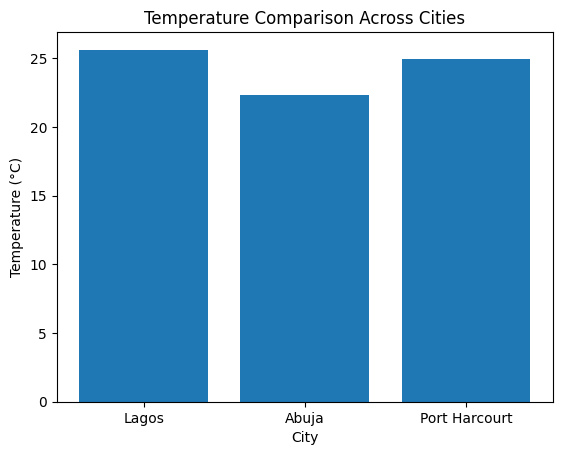

In [21]:
import matplotlib.pyplot as plt

plt.bar(df["City"], df["Temperature"])
plt.title("Temperature Comparison Across Cities")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.show()

In [22]:
df.to_excel("weather_etl_output.xlsx", index=False)

In [23]:
import os
print(os.getcwd())

/content


In [25]:
from google.colab import files

In [26]:
files.download("weather_etl_output.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>